### Lab 05 – Izhikevich Spiking Neuron Model

In this lab, you will implement the Izhikevich neuron model and simulate different biological firing patterns such as regular spiking, fast spiking, and bursting.

You will complete missing code inside `models/izhikevich.py`.

In [5]:
pip install matplotlib

  Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pillow-12.1.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl (8.2 MB)
Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 902.9 kB/s  0:00:03 eta 0:00:01
Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl (64 kB)
Using cached pillow-12.1.1-cp314-cp314-macosx_11_0_arm64.whl (4.7 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplo

In [ ]:
pip install numpy


SyntaxError: invalid syntax (2629995517.py, line 1)

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from config import DT, T_TOTAL, I_CONST
from config import REGULAR_SPIKING, FAST_SPIKING, BURSTING
from models.izhikevich import simulate_izhikevich
from utils.plotting import plot_trace, plot_multiple_traces
from utils.metrics import firing_rate, isi, spike_count

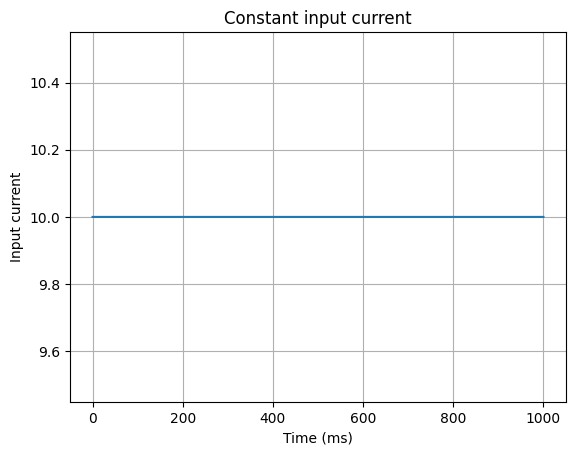

In [8]:
t = np.arange(0, T_TOTAL + DT, DT)
I = np.ones_like(t) * I_CONST

plt.figure()
plt.plot(t, I)
plt.title("Constant input current")
plt.xlabel("Time (ms)")
plt.ylabel("Input current")
plt.grid(True)
plt.show()

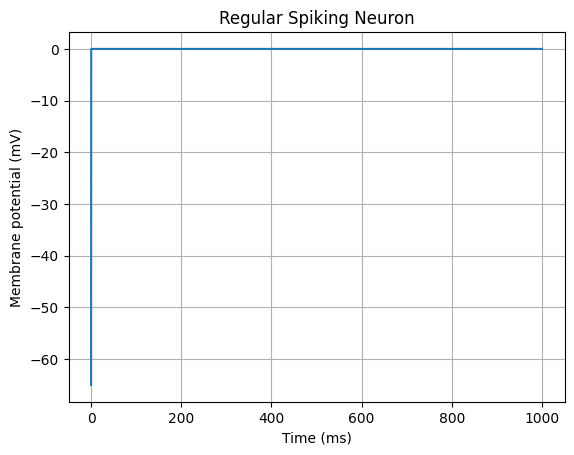

Spike count: 0
Firing rate (Hz): 0.0


In [9]:
# Run regular spiking neuron
params = REGULAR_SPIKING
v_rs, u_rs, sp_rs = simulate_izhikevich(I, t, **params)

plot_trace(t, v_rs, "Regular Spiking Neuron", "Membrane potential (mV)")
print("Spike count:", spike_count(sp_rs))
print("Firing rate (Hz):", firing_rate(sp_rs, 0, T_TOTAL))

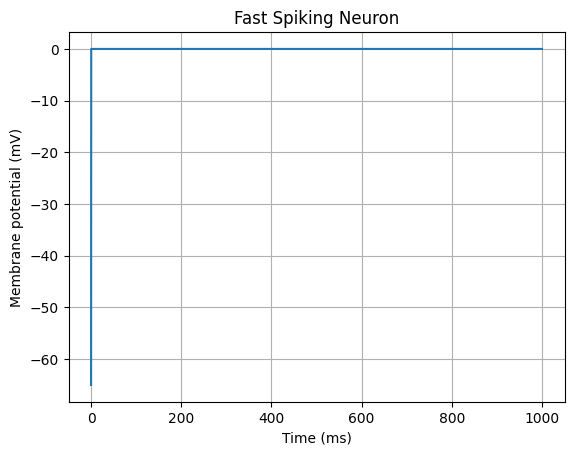

Spike count: 0
Firing rate (Hz): 0.0


In [10]:
# Fast spiking neuron
params = FAST_SPIKING
v_fs, u_fs, sp_fs = simulate_izhikevich(I, t, **params)

plot_trace(t, v_fs, "Fast Spiking Neuron", "Membrane potential (mV)")
print("Spike count:", spike_count(sp_fs))
print("Firing rate (Hz):", firing_rate(sp_fs, 0, T_TOTAL))

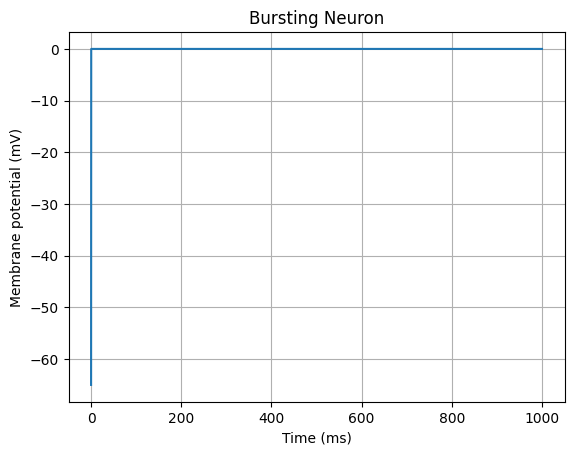

Spike count: 0
Firing rate (Hz): 0.0


In [11]:
# TODO 3:
# Bursting neuron
params = BURSTING
v_b, u_b, sp_b = simulate_izhikevich(I, t, **params)

plot_trace(t, v_b, "Bursting Neuron", "Membrane potential (mV)")
print("Spike count:", spike_count(sp_b))
print("Firing rate (Hz):", firing_rate(sp_b, 0, T_TOTAL))

In [17]:
def isi(spike_times):
    if len(spike_times) < 2:
        return np.array([])
    return np.diff(spike_times)

In [19]:
# TODO 5:
# Compute and print inter-spike intervals for the regular spiking neuron
rate = firing_rate(spikes, 0, T_TOTAL)

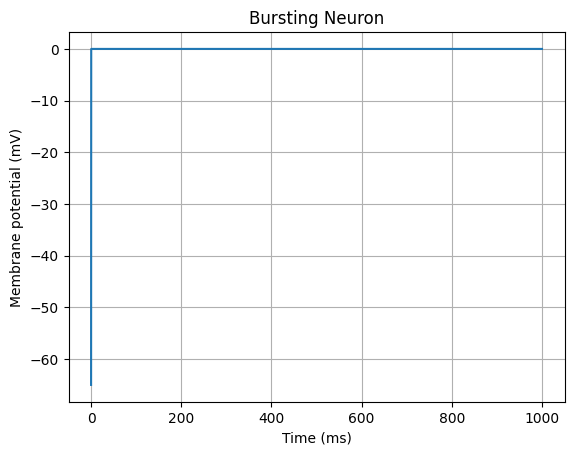

Spike count: 0
Firing rate (Hz): 0.0
Inter-spike intervals (ms): []


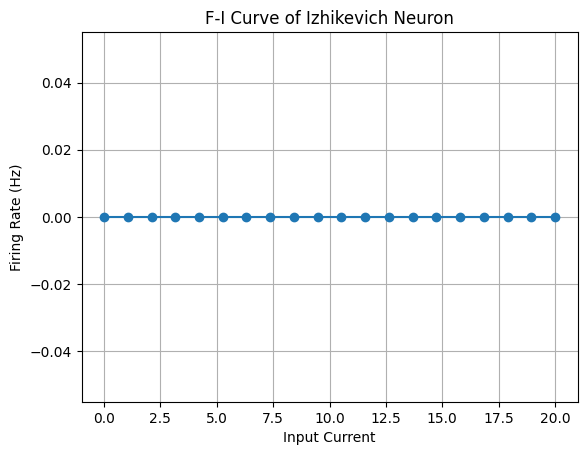

In [21]:
# Bursting neuron
params = BURSTING
v_b, u_b, sp_b = simulate_izhikevich(I, t, **params)

plot_trace(t, v_b, "Bursting Neuron", "Membrane potential (mV)")
print("Spike count:", spike_count(sp_b))
print("Firing rate (Hz):", firing_rate(sp_b, 0, T_TOTAL))


# Inter-spike intervals (Regular Spiking)
isi_values = isi(sp_rs)
print("Inter-spike intervals (ms):", isi_values)


# F-I Curve Analysis
currents = np.linspace(0, 20, 20)
rates = []

for I_value in currents:
    
    I = np.ones_like(t) * I_value
    
    v, u, spikes = simulate_izhikevich(I, t, **REGULAR_SPIKING)
    
    rate = firing_rate(spikes, 0, T_TOTAL)
    
    rates.append(rate)


plt.figure()
plt.plot(currents, rates, marker='o')
plt.xlabel("Input Current")
plt.ylabel("Firing Rate (Hz)")
plt.title("F-I Curve of Izhikevich Neuron")
plt.grid(True)
plt.show()

In [ ]:
## TODO 7 – Short Comparison (3–5 sentences)

# Compare the Izhikevich neuron with the LIF neuron from Lab 4.

# Discuss:
# - biological realism
# - number of firing patterns
# - computational cost
# - when each model is useful
"""ArithmeticError
The Izhikevich neuron model is more biologically realistic than the LIF model because 
it can reproduce many firing patterns observed in real neurons,
including regular spiking, fast spiking, and bursting. 
The LIF model uses a simple threshold-reset mechanism, 
which makes it computationally efficient 
but unable to capture complex dynamics. 
The Izhikevich model introduces a recovery 
variable that models neuronal adaptation while 
remaining computationally lightweight compared 
to detailed conductance-based models.
Therefore, LIF is useful for large-scale neural network simulations,
 while the Izhikevich model is preferred when realistic spike behavior 
is required."""